# Fine-tuning SAM on Carotid Ultrasound (PyTorch Lightning)

Fine-tunes a **promptable Segment Anything Model (SAM)** mask-decoder on a carotid ultrasound
segmentation dataset (RGB images + binary expert masks). The vision/prompt encoders are frozen;
only the lightweight mask decoder is trained, prompted with a **bounding box** derived from each
mask.

**Self-contained & portable** — every setting lives in the `CONFIG` cell below. To run elsewhere,
change `ROOT_DIR` (or set the `CAROTID_ROOT` env var) and run top-to-bottom.

- Images loaded with `torchvision.io.read_image`.
- Series-aware 70/15/15 split (no slice leakage) saved as CSVs under `splits/`.
- Best model (max `val/dice`) checkpointed under `results/sam_ckpts/`.

In [1]:
# Cell 1 — install deps (safe to re-run; skip if already present)
# %pip install -q transformers lightning torchmetrics

In [2]:
# Cell 2 — imports
import os, re, csv, glob, random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
from transformers import SamModel, SamProcessor
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score
import matplotlib.pyplot as plt

/home/gokul/miniconda3/envs/cyient/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Cell 3 — CONFIG (single source of truth; edit ROOT_DIR to run elsewhere)
CONFIG = dict(
    # --- data ---
    ROOT_DIR    = os.environ.get("CAROTID_ROOT", "data/sample_images/carotid"),
    IMG_SUBDIR  = "US images",
    MASK_SUBDIR = "Expert mask images",
    OUTPUT_DIR  = os.environ.get("SAM_OUTPUT", "."),   # splits/ and results/ written here
    # --- model ---
    MODEL_ID    = "facebook/sam-vit-base",   # swap to a MedSAM HF id (e.g. "wanglab/medsam-vit-base") for a medical init
    FREEZE_ENCODERS = True,                  # train only the mask decoder
    # --- training ---
    BATCH_SIZE  = 2,
    LR          = 1e-4,
    MAX_EPOCHS  = 10,
    PATIENCE    = 5,
    PRECISION   = "16-mixed",
    NUM_WORKERS = 4,
    MASK_OUT    = 256,                        # SAM mask-decoder output resolution
    BOX_JITTER  = 10,                         # px jitter on train box prompts (0 = off)
    SUBSET      = None,                       # set to an int for a quick smoke run
    SEED        = 42,
    # --- split ---
    SPLIT = (0.70, 0.15, 0.15),
    FORCE_SPLIT = False,                      # regenerate split CSVs even if they exist
)
SPLIT_DIR = os.path.join(CONFIG["OUTPUT_DIR"], "splits")
CKPT_DIR  = os.path.join(CONFIG["OUTPUT_DIR"], "results", "sam_ckpts")
os.makedirs(SPLIT_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)
L.seed_everything(CONFIG["SEED"])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| root:", CONFIG["ROOT_DIR"])

Seed set to 42


device: cuda | root: /home/gokul/github_repos/cyient/data/sample_images/carotid


In [4]:
# Cell 4 — series-aware split -> splits/{train,val,test}.csv
SERIES_RE = re.compile(r"_slice_\d+\.(png|jpg|jpeg|bmp|tif|tiff)$", re.I)
def series_of(fname): return SERIES_RE.sub("", os.path.basename(fname))

def build_splits():
    img_dir  = os.path.join(CONFIG["ROOT_DIR"], CONFIG["IMG_SUBDIR"])
    mask_dir = os.path.join(CONFIG["ROOT_DIR"], CONFIG["MASK_SUBDIR"])
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    assert imgs, f"no images under {img_dir}"
    rows = []
    for ip in imgs:
        mp = os.path.join(mask_dir, os.path.basename(ip))
        if os.path.exists(mp):
            rows.append(dict(image_path=ip, mask_path=mp, series=series_of(ip)))
    # group by series, shuffle series, split by series (no slice leakage)
    series = sorted({r["series"] for r in rows})
    rng = random.Random(CONFIG["SEED"]); rng.shuffle(series)
    n = len(series); n_tr = int(CONFIG["SPLIT"][0]*n); n_va = int(CONFIG["SPLIT"][1]*n)
    groups = {"train": set(series[:n_tr]), "val": set(series[n_tr:n_tr+n_va]), "test": set(series[n_tr+n_va:])}
    for r in rows:
        r["split"] = next(s for s, S in groups.items() if r["series"] in S)
    for split in ("train","val","test"):
        srows = [r for r in rows if r["split"]==split]
        with open(os.path.join(SPLIT_DIR, f"{split}.csv"), "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=["image_path","mask_path","series","split"]); w.writeheader(); w.writerows(srows)
    return groups

paths = {s: os.path.join(SPLIT_DIR, f"{s}.csv") for s in ("train","val","test")}
if CONFIG["FORCE_SPLIT"] or not all(os.path.exists(p) for p in paths.values()):
    build_splits()

def load_rows(split):
    with open(paths[split]) as f: return list(csv.DictReader(f))
splits = {s: load_rows(s) for s in ("train","val","test")}
series_by = {s: {r["series"] for r in splits[s]} for s in splits}
print({s: (len(splits[s]), len(series_by[s])) for s in splits}, "(images, #series)")
assert not (series_by["train"] & series_by["val"]) and not (series_by["train"] & series_by["test"]) \
       and not (series_by["val"] & series_by["test"]), "series leak across splits!"
print("series disjoint across splits: OK")

{'train': (730, 26), 'val': (90, 5), 'test': (280, 7)} (images, #series)
series disjoint across splits: OK


In [5]:
# Cell 5 — Dataset (torchvision.io) + box prompt from mask + loaders
PROCESSOR = SamProcessor.from_pretrained(CONFIG["MODEL_ID"])

def box_from_mask(mbin, W, H, jitter=0):
    ys, xs = np.where(mbin > 0)
    if len(xs) == 0:
        return [0, 0, W - 1, H - 1]                      # empty mask -> whole-image box
    x0, y0, x1, y1 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())
    if jitter:
        x0 = max(0, x0 - random.randint(0, jitter)); y0 = max(0, y0 - random.randint(0, jitter))
        x1 = min(W - 1, x1 + random.randint(0, jitter)); y1 = min(H - 1, y1 + random.randint(0, jitter))
    return [x0, y0, x1, y1]

class CarotidSamDataset(Dataset):
    def __init__(self, rows, train=False):
        self.rows, self.train = rows, train
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows[i]
        img = read_image(r["image_path"], ImageReadMode.RGB)      # (3,H,W) uint8
        msk = read_image(r["mask_path"],  ImageReadMode.GRAY)     # (1,H,W) uint8
        H, W = img.shape[1], img.shape[2]
        mbin = (msk[0].numpy() > 127).astype(np.uint8)
        box  = box_from_mask(mbin, W, H, jitter=CONFIG["BOX_JITTER"] if self.train else 0)
        enc  = PROCESSOR(images=img.permute(1, 2, 0).numpy(), input_boxes=[[box]], return_tensors="pt")
        lab  = torch.from_numpy(mbin)[None, None].float()
        lab  = F.interpolate(lab, size=(CONFIG["MASK_OUT"], CONFIG["MASK_OUT"]), mode="nearest")[0]
        return dict(pixel_values=enc["pixel_values"][0], input_boxes=enc["input_boxes"][0], label=lab)

def collate(b):
    return dict(
        pixel_values=torch.stack([x["pixel_values"] for x in b]),
        input_boxes =torch.stack([x["input_boxes"]  for x in b]),
        label       =torch.stack([x["label"]        for x in b]),
    )

def make_loader(split, train=False):
    rows = splits[split]
    if CONFIG["SUBSET"]: rows = rows[:CONFIG["SUBSET"]]
    return DataLoader(CarotidSamDataset(rows, train=train),
                      batch_size=CONFIG["BATCH_SIZE"] if train else 1, shuffle=train,
                      num_workers=CONFIG["NUM_WORKERS"], collate_fn=collate, pin_memory=True)

train_loader, val_loader, test_loader = make_loader("train", True), make_loader("val"), make_loader("test")
print("batches:", {"train": len(train_loader), "val": len(val_loader), "test": len(test_loader)})

batches: {'train': 365, 'val': 90, 'test': 280}


In [6]:
# Cell 6 — LightningModule: freeze encoders, train mask decoder (Dice+BCE)
class SamFinetuner(L.LightningModule):
    def __init__(self, cfg):
        super().__init__(); self.save_hyperparameters(cfg)
        self.cfg = cfg
        self.model = SamModel.from_pretrained(cfg["MODEL_ID"])
        if cfg["FREEZE_ENCODERS"]:
            for p in self.model.vision_encoder.parameters(): p.requires_grad_(False)
            for p in self.model.prompt_encoder.parameters(): p.requires_grad_(False)
        self.val_iou, self.val_dice = BinaryJaccardIndex(), BinaryF1Score()
        self.test_iou, self.test_dice = BinaryJaccardIndex(), BinaryF1Score()

    def _logits(self, batch):
        if self.cfg["FREEZE_ENCODERS"]:
            with torch.no_grad():
                emb = self.model.get_image_embeddings(batch["pixel_values"])
            out = self.model(image_embeddings=emb, input_boxes=batch["input_boxes"], multimask_output=False)
        else:
            out = self.model(pixel_values=batch["pixel_values"], input_boxes=batch["input_boxes"], multimask_output=False)
        return out.pred_masks[:, 0, 0]            # (B, 256, 256)

    @staticmethod
    def _loss(logits, target):
        bce = F.binary_cross_entropy_with_logits(logits, target)
        p = torch.sigmoid(logits)
        num = 2 * (p * target).sum((-1, -2)) + 1.0
        den = p.sum((-1, -2)) + target.sum((-1, -2)) + 1.0
        return bce + (1.0 - (num / den).mean())

    def training_step(self, batch, _):
        logits = self._logits(batch); tgt = batch["label"][:, 0]
        loss = self._loss(logits, tgt)
        self.log("train/loss", loss, prog_bar=True, batch_size=tgt.size(0)); return loss

    def validation_step(self, batch, _):
        logits = self._logits(batch); tgt = batch["label"][:, 0]
        loss = self._loss(logits, tgt)
        pred = (torch.sigmoid(logits) > 0.5).long(); t = tgt.long()
        self.val_iou.update(pred, t); self.val_dice.update(pred, t)
        self.log("val/loss", loss, prog_bar=True, batch_size=tgt.size(0))
    def on_validation_epoch_end(self):
        self.log("val/iou", self.val_iou.compute(), prog_bar=True)
        self.log("val/dice", self.val_dice.compute(), prog_bar=True)
        self.val_iou.reset(); self.val_dice.reset()

    def test_step(self, batch, _):
        logits = self._logits(batch); t = batch["label"][:, 0].long()
        pred = (torch.sigmoid(logits) > 0.5).long()
        self.test_iou.update(pred, t); self.test_dice.update(pred, t)
    def on_test_epoch_end(self):
        self.log("test/iou", self.test_iou.compute()); self.log("test/dice", self.test_dice.compute())
        self.test_iou.reset(); self.test_dice.reset()

    def configure_optimizers(self):
        params = [p for p in self.model.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(params, lr=self.cfg["LR"])
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.cfg["MAX_EPOCHS"])
        return {"optimizer": opt, "lr_scheduler": sch}

In [7]:
# Cell 7 — train; ModelCheckpoint saves the best (max val/dice)
ckpt_cb = ModelCheckpoint(monitor="val/dice", mode="max", save_top_k=1,
                          dirpath=CKPT_DIR, filename="sam-carotid-best",
                          auto_insert_metric_name=False)
early_cb = EarlyStopping(monitor="val/dice", mode="max", patience=CONFIG["PATIENCE"])

model = SamFinetuner(CONFIG)
trainer = L.Trainer(max_epochs=CONFIG["MAX_EPOCHS"], accelerator="gpu", devices=1,
                    precision=CONFIG["PRECISION"], callbacks=[ckpt_cb, early_cb],
                    log_every_n_steps=10, default_root_dir=CONFIG["OUTPUT_DIR"])
trainer.fit(model, train_loader, val_loader)
print("best checkpoint:", ckpt_cb.best_model_path)
print("best val/dice :", float(ckpt_cb.best_model_score))

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 7076.45it/s]


Using 16bit Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


...

/home/gokul/miniconda3/envs/cyient/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/gokul/miniconda3/envs/cyient/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/gokul/miniconda3/envs/cyient/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 241 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=10` reached.


best checkpoint: /home/gokul/github_repos/cyient/results/sam_ckpts/sam-carotid-best.ckpt
best val/dice : 0.9547533392906189


In [8]:
# Cell 8 — evaluate best checkpoint on the held-out test split
test_metrics = trainer.test(model, test_loader, ckpt_path="best")
print(test_metrics)

Restoring states from the checkpoint path at /home/gokul/github_repos/cyient/results/sam_ckpts/sam-carotid-best.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loaded model weights from the checkpoint at /home/gokul/github_repos/cyient/results/sam_ckpts/sam-carotid-best.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/dice         │    0.9510185122489929     │
│         test/iou          │    0.9066113233566284     │
└───────────────────────────┴───────────────────────────┘

[{'test/iou': 0.9066113233566284, 'test/dice': 0.9510185122489929}]


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loading weights:  81%|████████  | 255/314 [00:00<00:00, 2547.35it/s]

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 2326.78it/s]

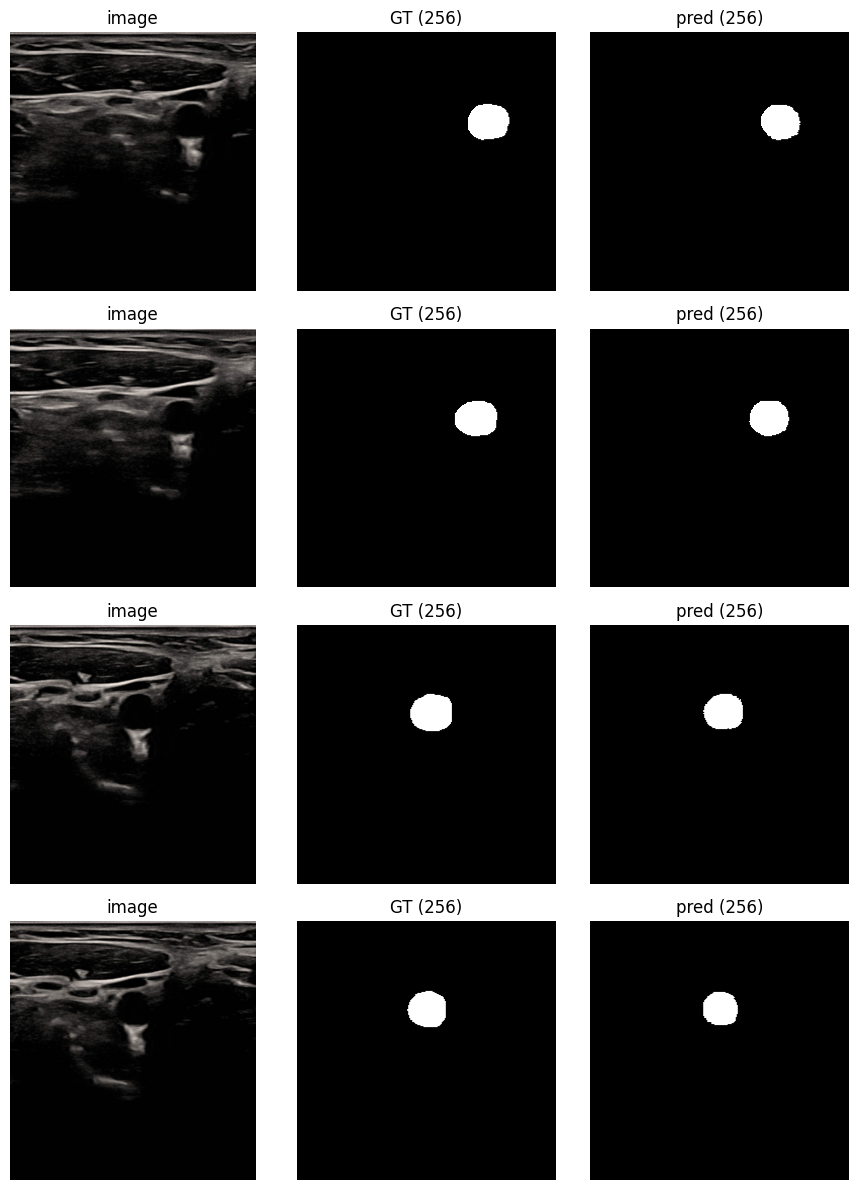

In [9]:
# Cell 9 — visualize predicted vs ground-truth masks on test images
best = SamFinetuner.load_from_checkpoint(ckpt_cb.best_model_path, cfg=CONFIG).to(DEVICE).eval()
ds = CarotidSamDataset(splits["test"][:6], train=False)
n = min(4, len(ds))
fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    s = ds[i]
    with torch.no_grad():
        logit = best._logits({k: v[None].to(DEVICE) for k, v in s.items()})[0]
        pred = (torch.sigmoid(logit) > 0.5).cpu().numpy().astype(float)
    img = read_image(splits["test"][i]["image_path"], ImageReadMode.RGB).permute(1, 2, 0).numpy()
    gt = s["label"][0].numpy()
    ax[i, 0].imshow(img);  ax[i, 0].set_title("image");      ax[i, 0].axis("off")
    ax[i, 1].imshow(gt, cmap="gray");   ax[i, 1].set_title("GT (256)");   ax[i, 1].axis("off")
    ax[i, 2].imshow(pred, cmap="gray"); ax[i, 2].set_title("pred (256)"); ax[i, 2].axis("off")
plt.tight_layout(); plt.show()

## Notes

- **Prompting.** Training and the demo above use a **bounding-box prompt** derived from the mask
  (the standard SAM fine-tune signal). At inference you must supply a box or point prompt; for
  fully automatic masks use `SamAutomaticMaskGenerator` (a grid of point prompts).
- **Medical init.** `CONFIG["MODEL_ID"]` defaults to `facebook/sam-vit-base`. For a medical
  starting point, swap in a MedSAM HF checkpoint (e.g. `wanglab/medsam-vit-base`).
- **Reload best model:** `SamFinetuner.load_from_checkpoint(path, cfg=CONFIG)`.
- **Scale up:** raise `MAX_EPOCHS`, set `FREEZE_ENCODERS=False` to also fine-tune the encoder
  (more memory), or increase `BATCH_SIZE`. Set `SUBSET` to an int for a quick smoke run.